# Deep Learning Training (Neural Networks) - 14-Day Horizon
This notebook trains 5 neural architectures across 6 commodities for a **14-Day horizon**:
1. **LSTM** (Standard Recurrent)
2. **GRU** (Gated Recurrent Unit, lighter)
3. **Transformer** (Multi-head Self Attention)
4. **N-BEATS** (Neural Basis Expansion - Pure Forecasting)
5. **TFT** (Temporal Fusion Transformer - Interpretable)

Includes dynamic 14-day target calculation, increased patience (20) for overlapping targets, and live loss curves.

In [1]:
import pandas as pd
import numpy as np
import os
import json
import warnings
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import copy
import joblib
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from IPython.display import display, clear_output

warnings.filterwarnings('ignore')

# CONFIGURATION
HORIZON = 14

data_dir = './data'
results_dir = './results'
models_dir = './models'
os.makedirs(results_dir, exist_ok=True)
os.makedirs(models_dir, exist_ok=True)
commodities = ['gold', 'silver', 'copper', 'natural_gas', 'crude_oil', 'wheat']

SEQ_LENGTH = 10
BATCH_SIZE = 32
EPOCHS = 150
PATIENCE = 20 # Increased from 15 due to 14-day overlapping noise
LR = 0.001
HIDDEN_SIZE = 32

torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Running on: {device}")
if torch.cuda.is_available():
    print(f"Device Name: {torch.cuda.get_device_name(0)}")


Running on: cuda
Device Name: NVIDIA RTX A6000


In [2]:
datasets = {}
print("Loading datasets...")
for name in commodities:
    file_path = os.path.join(data_dir, f"{name}.csv")
    if os.path.exists(file_path):
        df = pd.read_csv(file_path, index_col='Date', parse_dates=True)
        datasets[name] = df


Loading datasets...


In [3]:
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers=1, batch_first=True)
        self.dropout = nn.Dropout(0.2)
        self.fc = nn.Linear(hidden_size, 1)
        
    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.dropout(out[:, -1, :])
        return self.fc(out)

class GRUModel(nn.Module):
    def __init__(self, input_size, hidden_size):
        super(GRUModel, self).__init__()
        self.gru = nn.GRU(input_size, hidden_size, num_layers=1, batch_first=True)
        self.dropout = nn.Dropout(0.2)
        self.fc = nn.Linear(hidden_size, 1)
        
    def forward(self, x):
        out, _ = self.gru(x)
        out = self.dropout(out[:, -1, :])
        return self.fc(out)


In [4]:
class TransformerModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_heads=4):
        super(TransformerModel, self).__init__()
        self.input_proj = nn.Linear(input_size, hidden_size)
        encoder_layer = nn.TransformerEncoderLayer(d_model=hidden_size, nhead=num_heads, batch_first=True, dropout=0.2)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=1)
        self.dropout = nn.Dropout(0.2)
        self.fc = nn.Linear(hidden_size, 1)
        
    def forward(self, x):
        x = self.input_proj(x)
        out = self.transformer_encoder(x)
        out = self.dropout(out[:, -1, :])
        return self.fc(out)


In [5]:
# Simplified Custom N-BEATS 
class NBeatsBlock(nn.Module):
    def __init__(self, input_size, theta_size, hidden_size=128):
        super(NBeatsBlock, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.fc3 = nn.Linear(hidden_size, theta_size)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)
        
    def forward(self, x):
        h = self.dropout(self.relu(self.fc1(x)))
        h = self.dropout(self.relu(self.fc2(h)))
        return self.fc3(h)

class NBeatsModel(nn.Module):
    def __init__(self, seq_length, num_features):
        super(NBeatsModel, self).__init__()
        self.input_size = seq_length * num_features
        # 3 blocks
        self.block1 = NBeatsBlock(self.input_size, self.input_size + 1)
        self.block2 = NBeatsBlock(self.input_size, self.input_size + 1)
        self.block3 = NBeatsBlock(self.input_size, self.input_size + 1)
        
    def forward(self, x):
        batch_size = x.size(0)
        x = x.view(batch_size, -1) # Flatten
        
        # Block 1
        theta1 = self.block1(x)
        backcast1, forecast4 = theta1[:, :-1], theta1[:, -1:]
        x = x - backcast1 # Residual
        
        # Block 2
        theta2 = self.block2(x)
        backcast2, forecast5 = theta2[:, :-1], theta2[:, -1:]
        x = x - backcast2
        
        # Block 3
        theta3 = self.block3(x)
        forecast6 = theta3[:, -1:]
        
        return forecast4 + forecast5 + forecast6

# Simplified TFT (using Self-Attention and GRN concepts)
class GatedResidualNetwork(nn.Module):
    def __init__(self, hidden_size):
        super(GatedResidualNetwork, self).__init__()
        self.fc1 = nn.Linear(hidden_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.elu = nn.ELU()
        self.gate = nn.Linear(hidden_size, hidden_size)
        self.sigmoid = nn.Sigmoid()
        self.norm = nn.LayerNorm(hidden_size)
        
    def forward(self, x):
        h = self.elu(self.fc1(x))
        h = self.fc2(h)
        g = self.sigmoid(self.gate(x))
        out = self.norm(x + g * h)
        return out

class TFTModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_heads=4):
        super(TFTModel, self).__init__()
        self.input_proj = nn.Linear(input_size, hidden_size)
        self.grn = GatedResidualNetwork(hidden_size)
        self.attention = nn.MultiheadAttention(hidden_size, num_heads, batch_first=True, dropout=0.2)
        self.fc = nn.Linear(hidden_size, 1)
        
    def forward(self, x):
        x = self.input_proj(x)
        x = self.grn(x)
        attn_out, _ = self.attention(x, x, x)
        out = attn_out[:, -1, :] # Take last timestep
        return self.fc(out)


In [6]:
def train_dl_model(model, train_loader, val_loader, criterion, optimizer, model_name, comm_name):
    best_val_loss = float('inf')
    best_model_wts = copy.deepcopy(model.state_dict())
    epochs_no_improve = 0
    best_epoch = 0
    
    train_losses = []
    val_losses = []
    
    epoch_pbar = tqdm(range(EPOCHS), desc=f"{model_name} Epochs", leave=False)
    
    # Setup live plot safely without clearing cell
    fig, ax = plt.subplots(figsize=(6, 3))
    out_disp = display(fig, display_id=True)
    
    for epoch in epoch_pbar:
        model.train()
        t_loss = 0
        for batch_x, batch_y in train_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            optimizer.zero_grad()
            outputs = model(batch_x)
            loss = criterion(outputs.squeeze(), batch_y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            t_loss += loss.item() * batch_x.size(0)
            
        t_loss /= len(train_loader.dataset)
        train_losses.append(t_loss)
            
        model.eval()
        v_loss = 0
        with torch.no_grad():
            for batch_x, batch_y in val_loader:
                batch_x, batch_y = batch_x.to(device), batch_y.to(device)
                outputs = model(batch_x)
                loss = criterion(outputs.squeeze(), batch_y)
                v_loss += loss.item() * batch_x.size(0)
        v_loss /= len(val_loader.dataset)
        val_losses.append(v_loss)
        
        # Update progress bar text
        epoch_pbar.set_postfix({'Train': f'{t_loss:.5f}', 'Val': f'{v_loss:.5f}', 'Best': best_epoch})
        
        # Update Live Plot IN PLACE (preserves tqdm and previous metrics)
        if epoch % 5 == 0 or epoch == EPOCHS - 1:
            ax.clear()
            ax.plot(train_losses, label='Train Loss')
            ax.plot(val_losses, label='Val Loss')
            ax.set_title(f'{comm_name.upper()} - {model_name} Loss')
            ax.legend()
            out_disp.update(fig)
        
        if v_loss < best_val_loss:
            best_val_loss = v_loss
            best_model_wts = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
            best_epoch = epoch
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= PATIENCE:
                print(f"⛔ {model_name} Early Stopped at Epoch {epoch} | Best: {best_epoch}")
                break
                
    plt.close(fig)
    model.load_state_dict(best_model_wts)
    return model


In [7]:
def calculate_metrics(y_true, y_pred, y_true_prev):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    nonzero = y_true != 0
    mape = np.mean(np.abs((y_true[nonzero] - y_pred[nonzero]) / y_true[nonzero])) * 100
    r2 = r2_score(y_true, y_pred)
    actual_dir = np.sign(y_true - y_true_prev)
    pred_dir = np.sign(y_pred - y_true_prev)
    dir_acc = np.mean(actual_dir == pred_dir) * 100
    naive_mae = mean_absolute_error(y_true, y_true_prev)
    imp_pct = ((naive_mae - mae) / naive_mae) * 100 if naive_mae > 0 else 0
    return {
        'MAE': round(mae, 4), 'RMSE': round(rmse, 4), 'MAPE': round(mape, 2),
        'Dir_Acc': round(dir_acc, 2), 'R2': round(r2, 4),
        'Naive_MAE': round(naive_mae, 4), 'Improvement_Pct': round(imp_pct, 2)
    }

def create_sequences(X, y, prev_close, true_price, seq_length):
    xs, ys, prevs, trues = [], [], [], []
    for i in range(len(X) - seq_length):
        xs.append(X[i:(i+seq_length)])
        ys.append(y[i+seq_length - 1]) 
        prevs.append(prev_close[i+seq_length - 1])
        trues.append(true_price[i+seq_length - 1])
    return np.array(xs), np.array(ys), np.array(prevs), np.array(trues)


Commodities Master Loop:   0%|          | 0/6 [00:00<?, ?it/s]


Processing GOLD (14-Day Horizon)


LSTM Epochs:   0%|          | 0/150 [00:00<?, ?it/s]

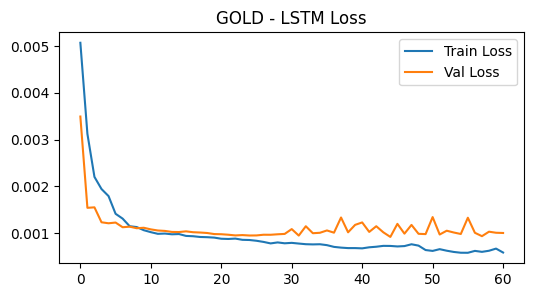

⛔ LSTM Early Stopped at Epoch 64 | Best: 44


GRU Epochs:   0%|          | 0/150 [00:00<?, ?it/s]

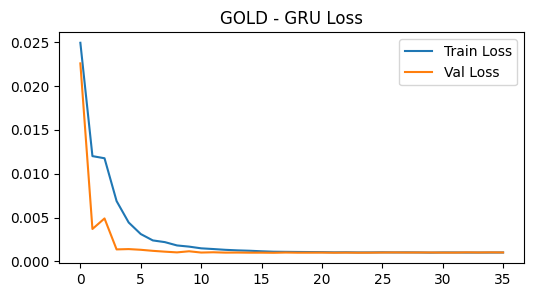

⛔ GRU Early Stopped at Epoch 36 | Best: 16


Transformer Epochs:   0%|          | 0/150 [00:00<?, ?it/s]

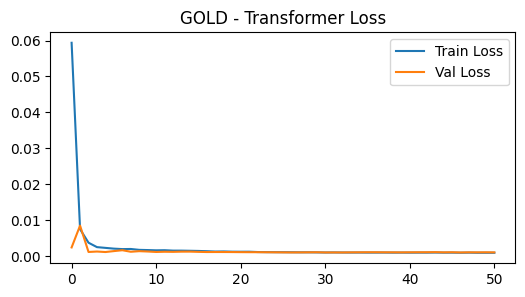

⛔ Transformer Early Stopped at Epoch 52 | Best: 32


N-BEATS Epochs:   0%|          | 0/150 [00:00<?, ?it/s]

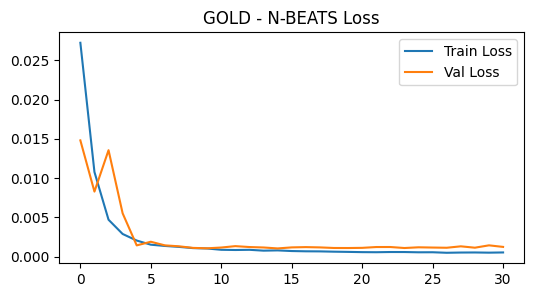

⛔ N-BEATS Early Stopped at Epoch 34 | Best: 14


TFT Epochs:   0%|          | 0/150 [00:00<?, ?it/s]

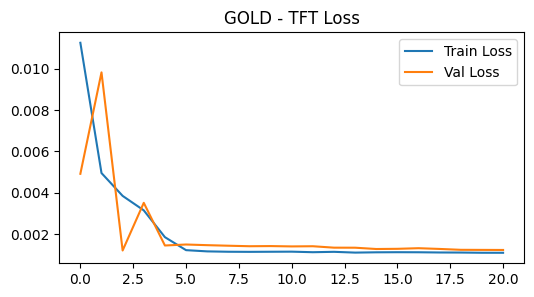

⛔ TFT Early Stopped at Epoch 22 | Best: 2


,MAE,RMSE,MAPE,Dir_Acc,R2,Naive_MAE,Improvement_Pct
LSTM,182.4820,246.9414,5.00,45.50,0.9216,129.7225,-40.67
GRU,149.2404,202.7641,4.18,36.33,0.9472,129.7225,-15.05
Transformer,130.3014,189.7172,3.59,61.90,0.9537,129.7225,-0.45
N-BEATS,151.7671,216.9626,4.15,42.93,0.9395,129.7225,-16.99
TFT,151.7694,211.8027,4.21,61.90,0.9423,129.7225,-17.00



Processing SILVER (14-Day Horizon)


LSTM Epochs:   0%|          | 0/150 [00:00<?, ?it/s]

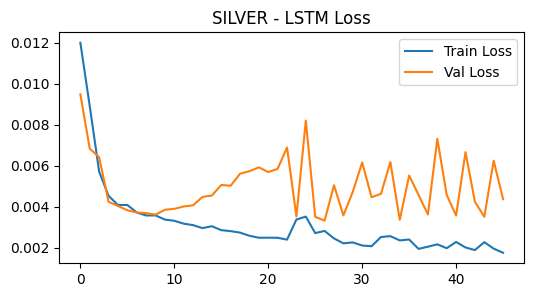

⛔ LSTM Early Stopped at Epoch 46 | Best: 26


GRU Epochs:   0%|          | 0/150 [00:00<?, ?it/s]

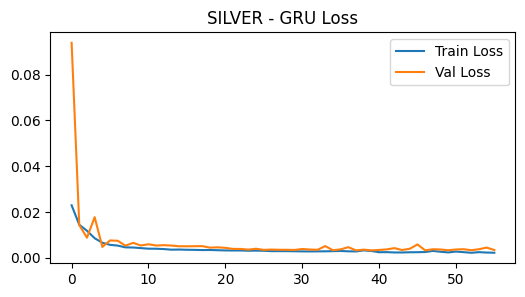

⛔ GRU Early Stopped at Epoch 57 | Best: 37


Transformer Epochs:   0%|          | 0/150 [00:00<?, ?it/s]

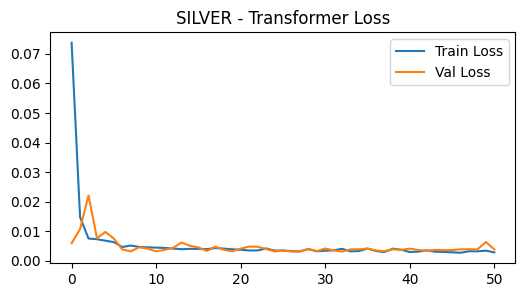

⛔ Transformer Early Stopped at Epoch 52 | Best: 32


N-BEATS Epochs:   0%|          | 0/150 [00:00<?, ?it/s]

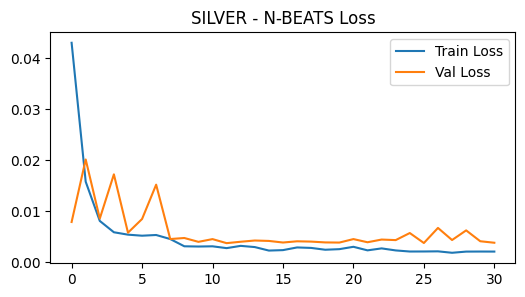

⛔ N-BEATS Early Stopped at Epoch 31 | Best: 11


TFT Epochs:   0%|          | 0/150 [00:00<?, ?it/s]

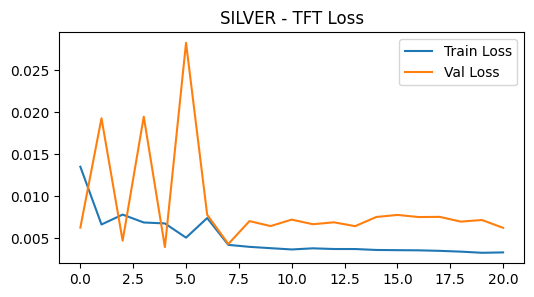

⛔ TFT Early Stopped at Epoch 24 | Best: 4


,MAE,RMSE,MAPE,Dir_Acc,R2,Naive_MAE,Improvement_Pct
LSTM,4.2620,7.1219,8.04,50.32,0.8698,4.0526,-5.17
GRU,4.2443,7.0892,7.95,51.93,0.8710,4.0526,-4.73
Transformer,3.9600,6.7657,7.32,57.23,0.8825,4.0526,2.28
N-BEATS,4.1166,6.7992,7.69,52.25,0.8814,4.0526,-1.58
TFT,3.8597,6.6174,7.13,65.11,0.8876,4.0526,4.76



Processing COPPER (14-Day Horizon)


LSTM Epochs:   0%|          | 0/150 [00:00<?, ?it/s]

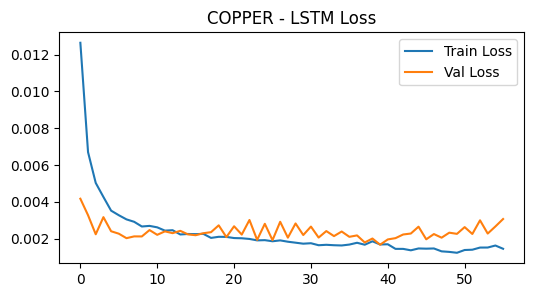

⛔ LSTM Early Stopped at Epoch 59 | Best: 39


GRU Epochs:   0%|          | 0/150 [00:00<?, ?it/s]

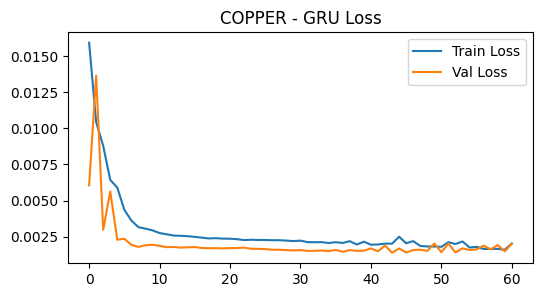

⛔ GRU Early Stopped at Epoch 63 | Best: 43


Transformer Epochs:   0%|          | 0/150 [00:00<?, ?it/s]

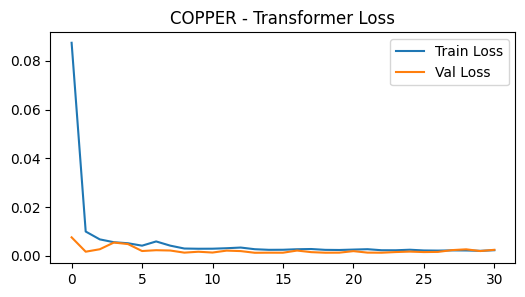

⛔ Transformer Early Stopped at Epoch 33 | Best: 13


N-BEATS Epochs:   0%|          | 0/150 [00:00<?, ?it/s]

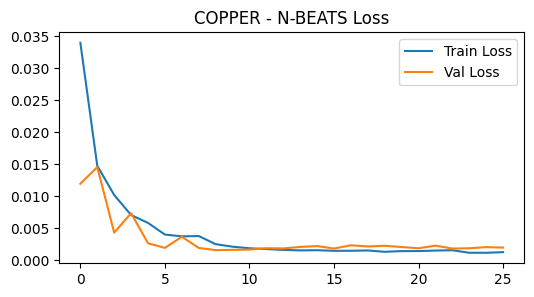

⛔ N-BEATS Early Stopped at Epoch 28 | Best: 8


TFT Epochs:   0%|          | 0/150 [00:00<?, ?it/s]

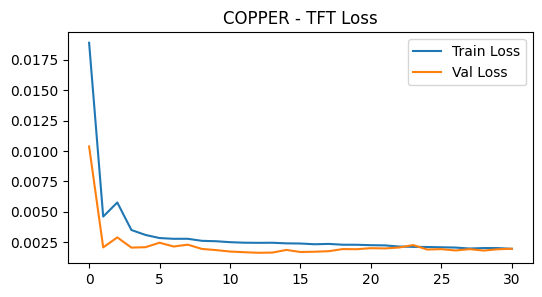

⛔ TFT Early Stopped at Epoch 32 | Best: 12


,MAE,RMSE,MAPE,Dir_Acc,R2,Naive_MAE,Improvement_Pct
LSTM,0.2630,0.3565,5.43,57.89,0.7611,0.2462,-6.80
GRU,0.2796,0.3609,5.71,53.33,0.7551,0.2462,-13.55
Transformer,0.2621,0.3330,5.25,48.42,0.7916,0.2462,-6.43
N-BEATS,0.2554,0.3423,5.24,57.02,0.7797,0.2462,-3.71
TFT,0.2472,0.3426,5.05,55.44,0.7793,0.2462,-0.41



Processing NATURAL_GAS (14-Day Horizon)


LSTM Epochs:   0%|          | 0/150 [00:00<?, ?it/s]

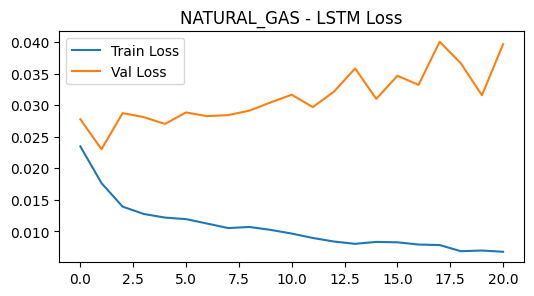

⛔ LSTM Early Stopped at Epoch 21 | Best: 1


GRU Epochs:   0%|          | 0/150 [00:00<?, ?it/s]

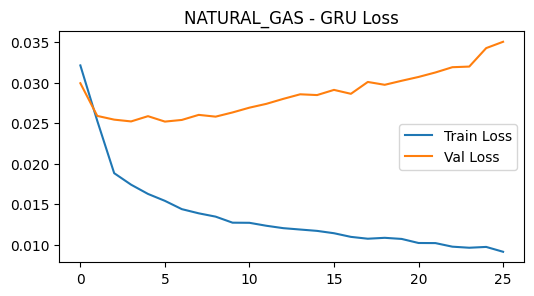

⛔ GRU Early Stopped at Epoch 25 | Best: 5


Transformer Epochs:   0%|          | 0/150 [00:00<?, ?it/s]

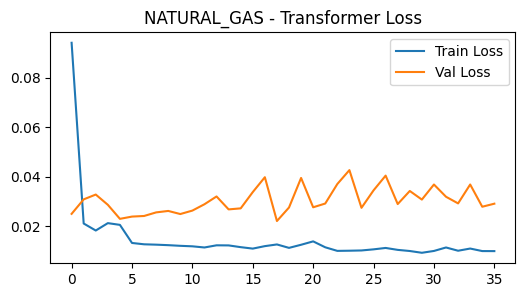

⛔ Transformer Early Stopped at Epoch 37 | Best: 17


N-BEATS Epochs:   0%|          | 0/150 [00:00<?, ?it/s]

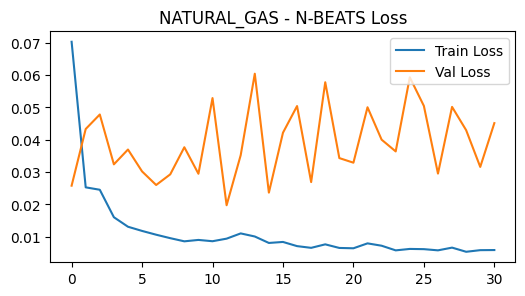

⛔ N-BEATS Early Stopped at Epoch 31 | Best: 11


TFT Epochs:   0%|          | 0/150 [00:00<?, ?it/s]

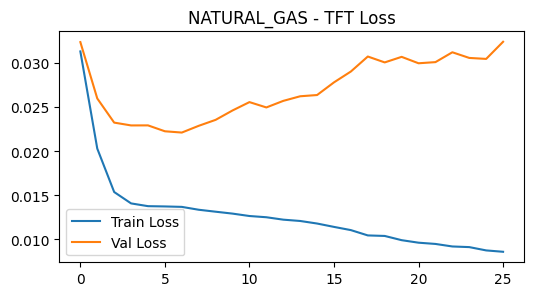

⛔ TFT Early Stopped at Epoch 26 | Best: 6


,MAE,RMSE,MAPE,Dir_Acc,R2,Naive_MAE,Improvement_Pct
LSTM,0.4434,0.7005,13.80,44.07,0.1671,0.3912,-13.34
GRU,0.4237,0.6470,13.27,50.80,0.2895,0.3912,-8.30
Transformer,0.5087,0.7080,16.08,48.56,0.1492,0.3912,-30.04
N-BEATS,0.4897,0.6623,15.08,46.31,0.2554,0.3912,-25.18
TFT,0.4010,0.6009,12.55,53.69,0.3871,0.3912,-2.51



Processing CRUDE_OIL (14-Day Horizon)


LSTM Epochs:   0%|          | 0/150 [00:00<?, ?it/s]

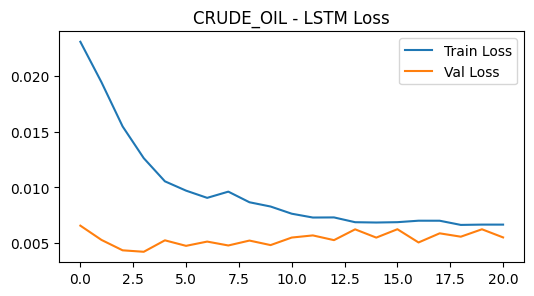

⛔ LSTM Early Stopped at Epoch 23 | Best: 3


GRU Epochs:   0%|          | 0/150 [00:00<?, ?it/s]

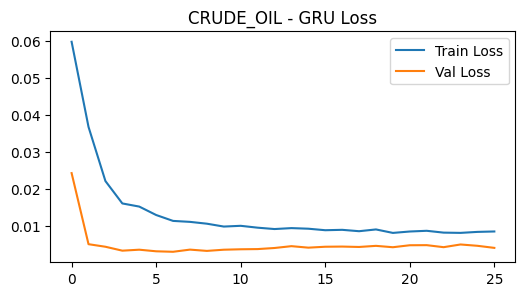

⛔ GRU Early Stopped at Epoch 26 | Best: 6


Transformer Epochs:   0%|          | 0/150 [00:00<?, ?it/s]

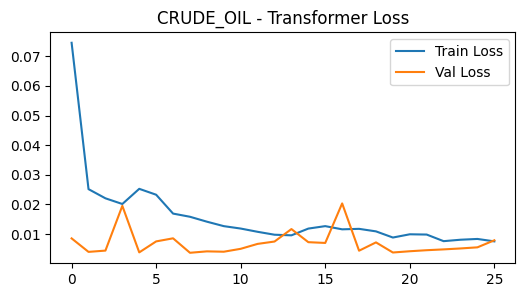

⛔ Transformer Early Stopped at Epoch 27 | Best: 7


N-BEATS Epochs:   0%|          | 0/150 [00:00<?, ?it/s]

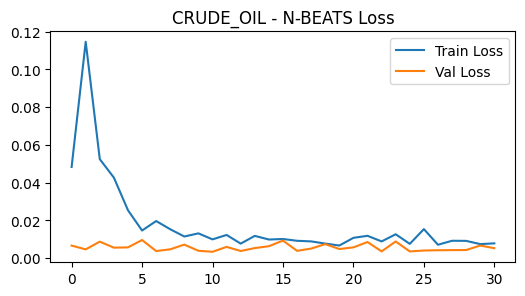

⛔ N-BEATS Early Stopped at Epoch 30 | Best: 10


TFT Epochs:   0%|          | 0/150 [00:00<?, ?it/s]

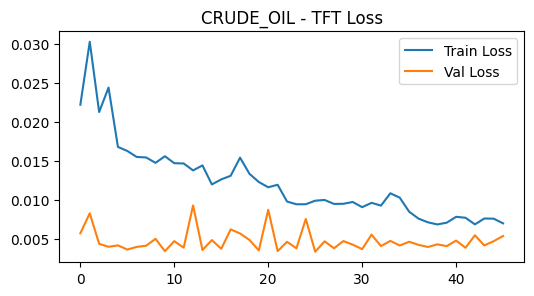

⛔ TFT Early Stopped at Epoch 45 | Best: 25


,MAE,RMSE,MAPE,Dir_Acc,R2,Naive_MAE,Improvement_Pct
LSTM,5.4547,8.3295,7.27,48.32,0.5222,4.9849,-9.43
GRU,5.1310,7.8253,6.74,50.69,0.5783,4.9849,-2.93
Transformer,5.8077,8.6185,7.84,47.92,0.4885,4.9849,-16.51
N-BEATS,5.2579,8.1525,6.86,49.90,0.5423,4.9849,-5.48
TFT,5.4153,7.7804,7.21,46.73,0.5832,4.9849,-8.64



Processing WHEAT (14-Day Horizon)


LSTM Epochs:   0%|          | 0/150 [00:00<?, ?it/s]

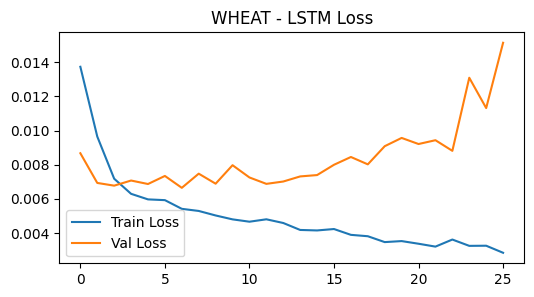

⛔ LSTM Early Stopped at Epoch 26 | Best: 6


GRU Epochs:   0%|          | 0/150 [00:00<?, ?it/s]

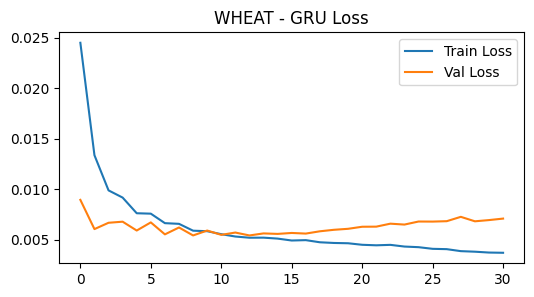

⛔ GRU Early Stopped at Epoch 32 | Best: 12


Transformer Epochs:   0%|          | 0/150 [00:00<?, ?it/s]

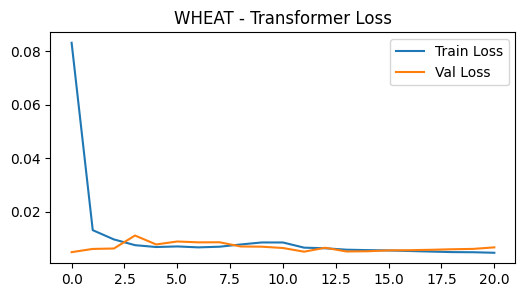

⛔ Transformer Early Stopped at Epoch 20 | Best: 0


N-BEATS Epochs:   0%|          | 0/150 [00:00<?, ?it/s]

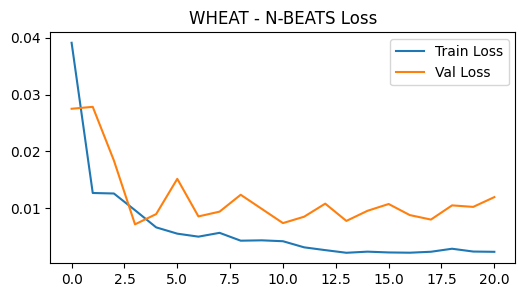

⛔ N-BEATS Early Stopped at Epoch 23 | Best: 3


TFT Epochs:   0%|          | 0/150 [00:00<?, ?it/s]

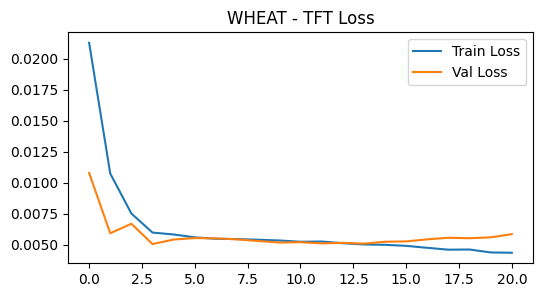

⛔ TFT Early Stopped at Epoch 23 | Best: 3


,MAE,RMSE,MAPE,Dir_Acc,R2,Naive_MAE,Improvement_Pct
LSTM,28.7775,37.1515,5.13,59.49,0.2667,25.6226,-12.31
GRU,26.1140,34.1438,4.65,59.81,0.3807,25.6226,-1.92
Transformer,28.6574,37.5528,5.07,56.75,0.2508,25.6226,-11.84
N-BEATS,39.9446,47.7694,7.22,54.98,-0.2123,25.6226,-55.90
TFT,26.0282,34.3023,4.61,55.79,0.3749,25.6226,-1.58


In [8]:
results = {}

for name, df in tqdm(datasets.items(), desc="Commodities Master Loop"):
    print(f"\n{'='*50}\nProcessing {name.upper()} ({HORIZON}-Day Horizon)\n{'='*50}")
    
    drop_cols = ['Target_Close_Next', 'Target_Return_Next', 'Target_Direction', 
                 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']
    features = [col for col in df.columns if col not in drop_cols]
    
    df_copy = df.copy()
    
    # Dynamic 14-day shifting
    df_copy[f'Target_Close_{HORIZON}d'] = df_copy['Close'].shift(-HORIZON)
    df_copy[f'Target_Return_{HORIZON}d'] = ((df_copy[f'Target_Close_{HORIZON}d'] - df_copy['Close']) / df_copy['Close']).clip(lower=-0.8, upper=1.5)
    
    # Drop NaNs at the end caused by shifting
    df_copy = df_copy.dropna(subset=[f'Target_Return_{HORIZON}d'])
    
    X = df_copy[features].values
    y_return = df_copy[f'Target_Return_{HORIZON}d'].values
    prev_close_arr = df_copy['Close'].values
    true_price_arr = df_copy[f'Target_Close_{HORIZON}d'].values
    
    total_len = len(X)
    train_end = int(total_len * 0.7)
    val_end = int(total_len * 0.8)
    
    X_train_raw, X_val_raw, X_test_raw = X[:train_end], X[train_end:val_end], X[val_end:]
    y_train_raw, y_val_raw, y_test_raw = y_return[:train_end], y_return[train_end:val_end], y_return[val_end:]
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_raw)
    X_val_scaled = scaler.transform(X_val_raw)
    X_test_scaled = scaler.transform(X_test_raw)
    joblib.dump(scaler, os.path.join(models_dir, f'{name}_scaler_{HORIZON}d.pkl'))
    
    p_c_train, p_c_val, p_c_test = prev_close_arr[:train_end], prev_close_arr[train_end:val_end], prev_close_arr[val_end:]
    t_p_train, t_p_val, t_p_test = true_price_arr[:train_end], true_price_arr[train_end:val_end], true_price_arr[val_end:]
    
    X_train_seq, y_train_seq, _, _ = create_sequences(X_train_scaled, y_train_raw, p_c_train, t_p_train, SEQ_LENGTH)
    X_val_seq, y_val_seq, _, _ = create_sequences(X_val_scaled, y_val_raw, p_c_val, t_p_val, SEQ_LENGTH)
    X_test_seq, y_test_seq, p_c_test_seq, t_p_test_seq = create_sequences(X_test_scaled, y_test_raw, p_c_test, t_p_test, SEQ_LENGTH)
    
    train_loader = DataLoader(TensorDataset(torch.tensor(X_train_seq, dtype=torch.float32), torch.tensor(y_train_seq, dtype=torch.float32)), batch_size=BATCH_SIZE, shuffle=False)
    val_loader = DataLoader(TensorDataset(torch.tensor(X_val_seq, dtype=torch.float32), torch.tensor(y_val_seq, dtype=torch.float32)), batch_size=BATCH_SIZE, shuffle=False)
    
    X_test_t = torch.tensor(X_test_seq, dtype=torch.float32).to(device)
    input_size = X_train_seq.shape[2]
    criterion = nn.MSELoss()
    
    res = {}
    
    models_to_train = {
        'LSTM': LSTMModel(input_size, HIDDEN_SIZE).to(device),
        'GRU': GRUModel(input_size, HIDDEN_SIZE).to(device),
        'Transformer': TransformerModel(input_size, HIDDEN_SIZE).to(device),
        'N-BEATS': NBeatsModel(SEQ_LENGTH, input_size).to(device),
        'TFT': TFTModel(input_size, HIDDEN_SIZE).to(device)
    }
    
    for m_name, model in models_to_train.items():
        opt = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-5)
        model = train_dl_model(model, train_loader, val_loader, criterion, opt, m_name, name)
        
        # Inference
        model.eval()
        with torch.no_grad():
            preds = model(X_test_t).squeeze().cpu().numpy()
            
        price_preds = p_c_test_seq * (1 + preds)
        res[m_name] = calculate_metrics(t_p_test_seq, price_preds, p_c_test_seq)
        
        # Save model
        torch.save(model.state_dict(), os.path.join(models_dir, f'{name}_{m_name.lower().replace("-","")}_{HORIZON}d.pt'))
        
    results[name] = res
    display(pd.DataFrame(res).T)


In [9]:
out_path = os.path.join(results_dir, f'stage2_dl_metrics_{HORIZON}d.json')
with open(out_path, 'w') as f:
    json.dump(results, f, indent=4)
print(f"Metrics saved to {out_path}")


Metrics saved to ./results/stage2_dl_metrics_14d.json
